In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
# os.chdir("/content/drive/MyDrive/DO_AN_DS_KI_1_NAM_3/DS201/NLe/KG-building")
os.chdir("/content/drive/MyDrive/KG-building")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/KG-building'

## Set up environment

In [ ]:
%%capture
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install transformers
!pip install bert-score
!pip install py_vncorenlp
!pip install matplotlib tqdm pandas numpy

## Check up modules

### Config

In [ ]:
from model_module.config import Config

config = Config()
print(config)

print("\nKey settings:")
print(f"  Device: {config.device}")
print(f"  Tokenizer type: {config.tokenizer_type}")
print(f"  Batch size: {config.batch_size}")
print(f"  Vocab size: {config.vocab_size}")
print(f"  Max seq len: {config.max_seq_len}")
print(f"  ViHealthBERT model: {config.vihealthbert_model}")

print("\n Config loaded successfully!")

Model Configuration:
device                   : cuda
kg_triples_path          : knowledge_graph_triples.csv
neo4j_nodes_path         : neo4j_nodes.csv
neo4j_rels_path          : neo4j_relationships.csv
qa_dataset_path          : 6000_samples.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vihealthbert_vncorenlp
vocab_size               : 5000
max_seq_len              : 128
vihealthbert_model       : demdecuong/vihealthbert-base-word
use_vncorenlp            : True
vncorenlp_path           : ./vncorenlp
d_model                  : 256
num_heads                : 8
num_layers               : 3
d_ff                     : 1024
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 8
num_epochs               : 10
learning_rate            : 0.0001
weight_decay             : 0.01
grad_clip_norm           : 1.0
train_ratio       

### Load data

In [ ]:
from model_module.data_loader import (
    load_knowledge_graph_data,
    load_qa_dataset,
    print_qa_examples
)

kg_triples, neo4j_nodes, neo4j_rels = load_knowledge_graph_data(
    config.kg_triples_path,
    config.neo4j_nodes_path,
    config.neo4j_rels_path
)


print("\nSample KG triples:")
print(kg_triples.head(3))

print("\nSample nodes:")
print(neo4j_nodes.head(3))

print("\nSample relationships:")
print(neo4j_rels.head(3))

Loading Knowledge Graph data...
KG Triples: 30,955 triples
Nodes: 4,525 nodes
Relationships: 30,955 relationships

Statistics:
  Unique entities: 4,525
  Unique relations: 5

Sample KG triples:
              subject    predicate              object
0          VIÊM GAN B  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY
1          VIÊM GAN B  HAS_SYMPTOM  XUNG HUYẾT HANG VỊ
2  XUNG HUYẾT HANG VỊ  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY

Sample nodes:
              name:ID         :LABEL
0          VIÊM GAN B  DISEASESYMTOM
1  XUNG HUYẾT HANG VỊ  DISEASESYMTOM
2        CAO HUYẾT ÁP  DISEASESYMTOM

Sample relationships:
            :START_ID        :TYPE             :END_ID  confidence
0          VIÊM GAN B  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY    0.999892
1          VIÊM GAN B  HAS_SYMPTOM  XUNG HUYẾT HANG VỊ    0.999892
2  XUNG HUYẾT HANG VỊ  HAS_SYMPTOM   TRÀO NGƯỢC DẠ DÀY    0.999892


In [ ]:
qa_dataset = load_qa_dataset(config.qa_dataset_path)
print_qa_examples(qa_dataset, num_examples=3)

print("\n QA dataset loaded!")

print("\nFirst sample structure:")
sample = qa_dataset[0]
for key, value in sample.items():
    print(f"  {key}: {type(value)} = {value if not isinstance(value, (list, str)) or len(str(value)) < 50 else str(value)[:50]+'...'}")


Loading real QA dataset from 6000_samples.csv...
Dataset loaded: 6,379 samples
Columns: ['qa_id', 'question', 'entity_count', 'unique_entity_types', 'entity_types', 'entities', 'is_multihop', 'reasons', 'rule_based', 'answer', 'context_text', 'context_title', 'context_url', 'keyword', 'topic', 'entities_question', 'entities_answer', 'entities_context']

Multi-hop distribution:
is_multihop
True    6379
Name: count, dtype: int64

Processing dataset...


Processing QA: 100%|██████████| 6379/6379 [00:01<00:00, 5684.85it/s]


Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 (theo em hiểu đây cũng được xếp vào bệnh nền), t...
Answer: Đúng là một số bệnh lý tim mạch, hô hấp. . . mãn tính mà điều trị ổn định có thể...
Entities (5): ['điều trị', 'bệnh nền', 'tiêm', 'vaccine', 'Covid']

 QA dataset lo

### Knowledge Graph

In [ ]:
from model_module.knowledge_graph import MedicalKnowledgeGraph


medical_kg = MedicalKnowledgeGraph(
    neo4j_rels,
    min_confidence=config.kg_min_confidence
)

print(f'\n{medical_kg}')
print("\nMedical KG initialized!")


MedicalKnowledgeGraph(nodes=4525, edges=30955, relations=5)

Medical KG initialized!


In [ ]:
test_entities = qa_dataset[0]['entities'][:3]
print(f"Test entities: {test_entities}")

subgraph_entities, subgraph_edges = medical_kg.get_subgraph(test_entities, max_hops=2)
print(f"\nSubgraph entities ({len(subgraph_entities)}): {subgraph_entities[:5]}")
print(f"Subgraph edges: {len(subgraph_edges)} edges")

# Convert to PyG format
node_features, edge_index, entity_list = medical_kg.get_pyg_data(
    entities=test_entities,
    use_pretrained_emb=False,
    emb_dim=config.kg_emb_dim
)

print(f"\nPyG Format:")
print(f"  node_features.shape: {node_features.shape}")
print(f"  edge_index.shape: {edge_index.shape}")
print(f"  entity_list length: {len(entity_list)}")

print("\nKG operations working!")

Test entities: ['xước', 'tiê', 'tiêm']

Subgraph entities (3): ['tiê', 'tiêm', 'xước']
Subgraph edges: 0 edges

PyG Format:
  node_features.shape: torch.Size([3, 300])
  edge_index.shape: torch.Size([2, 0])
  entity_list length: 3

KG operations working!


In [ ]:
# # Download VnCoreNLP
# !mkdir -p vncorenlp
# !cd vncorenlp && wget -q https://github.com/vncorenlp/VnCoreNLP/raw/master/VnCoreNLP-1.2.jar
# !ls -lh vncorenlp/
# !cd vncorenlp && wget https://github.com/vncorenlp/VnCoreNLP/archive/refs/heads/master.zip
# !cd vncorenlp && unzip -q master.zip
# !cd vncorenlp && mv VnCoreNLP-master/* .
# !ls -la vncorenlp/
# Install vncorenlp package
!pip install vncorenlp

print("\n VnCoreNLP setup completed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=6ceffac81682d79c586e1e3adf80814b6f3db3099f5bb55860c9ce430937c964
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp

 VnCoreNLP setup completed!


In [ ]:
# Reload module để áp dụng changes
import importlib
import sys

from model_module.vihealthbert_tokenizer import ViHealthBERTTokenizer

tokenizer = ViHealthBERTTokenizer(
    model_name='demdecuong/vihealthbert-base-word',
    max_len=128,
    use_vncorenlp=True,
    vncorenlp_path='vncorenlp'
)

# Test
text = "Ông Nguyễn Văn A bị viêm gan B"
print(f"\nOriginal:   {text}")

segmented = tokenizer.word_segment(text)
print(f"Segmented:  {segmented}")

encoded = tokenizer.encode(text)
print(f"Encoded:    {encoded[:15]}...")

decoded = tokenizer.decode(encoded)
print(f"Decoded:    {decoded}")

# Check status
print(f"\nTokenizer status:")
print(f"  VnCoreNLP enabled: {tokenizer.use_vncorenlp}")
print(f"  VnCoreNLP object: {tokenizer.vncorenlp is not None}")

print("\n" + "="*70)
if tokenizer.use_vncorenlp and '_' in segmented:
    print("VnCoreNLP WORKING! Word segmentation successful!")
else:
    print("VnCoreNLP still not working")
print("="*70)

Initializing ViHealthBERT tokenizer: demdecuong/vihealthbert-base-word


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

✓ VnCoreNLP loaded from vncorenlp/VnCoreNLP-1.2.jar
✓ ViHealthBERT tokenizer initialized
  Model: demdecuong/vihealthbert-base-word
  Vocab size: 64001
  Max length: 128
  VnCoreNLP: Enabled

Original:   Ông Nguyễn Văn A bị viêm gan B
Segmented:  Ông Nguyễn_Văn_A bị viêm gan B
Encoded:    [0, 168, 1649, 768, 45, 1743, 2161, 1247, 2, 1, 1, 1, 1, 1, 1]...
Decoded:    Ông Nguyễn Văn A bị viêm gan B

Tokenizer status:
  VnCoreNLP enabled: True
  VnCoreNLP object: True

VnCoreNLP WORKING! Word segmentation successful!


### Dataset

In [ ]:
from model_module.dataset import KGQADataset, collate_fn
from torch.utils.data import DataLoader

# Create small dataset for testing
test_qa = qa_dataset[:10]

dataset = KGQADataset(
    qa_data=test_qa,
    kg=medical_kg,
    tokenizer=tokenizer,
    kg_emb_dim=config.kg_emb_dim
)

print(f"Dataset size: {len(dataset)}")

# Test __getitem__
sample = dataset[0]
print("\nSample structure:")
for key, value in sample.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    else:
        print(f"  {key}: {type(value)}")

print("\nDataset working!")

Dataset size: 10

Sample structure:
  question_ids: torch.Size([128])
  context_ids: torch.Size([128])
  answer_ids: torch.Size([128])
  kg_node_features: torch.Size([9, 300])
  kg_edge_index: torch.Size([2, 0])
  answer_text: <class 'str'>

Dataset working!


In [ ]:
dataloader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# Get one batch
batch = next(iter(dataloader))

print("Batch structure:")
for key, value in batch.items():
    if hasattr(value, 'shape'):
        print(f"  {key}: {value.shape}")
    elif isinstance(value, list) and len(value) > 0 and hasattr(value[0], 'x'):
        print(f"  {key}: List of {len(value)} PyG Data objects")
        print(f"    First object: x={value[0].x.shape}, edge_index={value[0].edge_index.shape}")
    else:
        print(f"  {key}: {type(value)}")

print("\nDataLoader working!")

Batch structure:
  question_ids: torch.Size([2, 128])
  context_ids: torch.Size([2, 128])
  answer_ids: torch.Size([2, 128])
  kg_node_features: torch.Size([2, 9, 300])
  kg_edge_index: <class 'list'>
  answer_texts: <class 'list'>

DataLoader working!


### Model

In [ ]:
from model_module.models import (
    PositionalEncoding,
    TextEmbedding,
    GNNEncoder,
    CrossAttention,
    TransformerBlock,
    KGEnhancedTransformer
)
import torch

model = KGEnhancedTransformer(
    vocab_size=len(tokenizer),
    d_model=config.d_model,
    num_heads=config.num_heads,
    num_layers=config.num_layers,
    d_ff=config.d_ff,
    kg_node_features=config.kg_emb_dim,
    gnn_hidden=config.gnn_hidden,
    gnn_type=config.gnn_type,
    gnn_layers=config.gnn_layers,
    dropout=config.dropout,
    output_size=len(tokenizer)
)

model = model.to(config.device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Statistics:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model size: {total_params * 4 / 1024 / 1024:.2f} MB")

print("\nModel initialized!")


Model Statistics:
  Total parameters: 35,872,513
  Trainable parameters: 35,872,513
  Model size: 136.84 MB

Model initialized!


In [ ]:
print("="*70)
print("TEST 6.2: Model Forward Pass")
print("="*70)

# Get one batch
batch = next(iter(dataloader))

# Move to device - CORRECTED for kg_edge_index
question_ids = batch['question_ids'].to(config.device)
context_ids = batch['context_ids'].to(config.device)
kg_node_features = batch['kg_node_features'].to(config.device)

# Move each edge_index tensor to device
kg_edge_index = [edge_idx.to(config.device) for edge_idx in batch['kg_edge_index']]

answer_ids = batch['answer_ids'].to(config.device)

print(f"Question shape: {question_ids.shape}")
print(f"Context shape: {context_ids.shape}")
print(f"Answer shape: {answer_ids.shape}")
print(f"KG node features shape: {kg_node_features.shape}")
print(f"KG edge_index: {len(kg_edge_index)} graphs")

# Forward pass
model.eval()
with torch.no_grad():
    output = model(
        question_ids=question_ids,
        context_ids=context_ids,
        kg_node_features=kg_node_features,
        kg_edge_index=kg_edge_index
    )

print(f"\nOutput shape: {output.shape}")
print(f"Expected: [batch_size={question_ids.size(0)}, seq_len={question_ids.size(1) + context_ids.size(1)}, vocab_size={len(tokenizer)}]")

# Check output
logits = output  # [batch, seq_len, vocab_size]
predictions = torch.argmax(logits, dim=-1)  # [batch, seq_len]
print(f"Predictions shape: {predictions.shape}")

print("\n Forward pass successful!")

TEST 6.2: Model Forward Pass
Question shape: torch.Size([2, 128])
Context shape: torch.Size([2, 128])
Answer shape: torch.Size([2, 128])
KG node features shape: torch.Size([2, 9, 300])
KG edge_index: 2 graphs

Output shape: torch.Size([2, 256, 64001])
Expected: [batch_size=2, seq_len=256, vocab_size=64001]
Predictions shape: torch.Size([2, 256])

 Forward pass successful!


In [ ]:
# Cell 13: Test train.py functions

from model_module.train import train_epoch, evaluate
import torch.nn as nn
import torch.optim as optim

# Setup for training
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 0 is PAD token
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

# Create train/val split
train_size = int(0.8 * len(qa_dataset))
train_qa = qa_dataset[:train_size]
val_qa = qa_dataset[train_size:train_size+20]  # Small val set for testing

train_dataset = KGQADataset(train_qa[:20], medical_kg, tokenizer, config.kg_emb_dim)
val_dataset = KGQADataset(val_qa[:10], medical_kg, tokenizer, config.kg_emb_dim)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

print("\nTraining setup ready!")

Train samples: 20
Val samples: 10

Training setup ready!


In [ ]:
# Unpack both loss and accuracy
train_loss, train_acc = train_epoch(
    model,
    train_loader,
    criterion,
    optimizer,
    config.device
)

print(f"\nTrain Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_acc:.2f}%")

# Evaluate - Also returns (loss, accuracy)
val_loss, val_acc = evaluate(
    model,
    val_loader,
    criterion,
    config.device
)

print(f"\nVal Loss: {val_loss:.4f}")
print(f"Val Accuracy: {val_acc:.2f}%")

print("\nTraining functions working!")

Training: 100%|██████████| 10/10 [00:01<00:00,  6.68it/s, loss=3.8059, acc=81.50%]



Train Loss: 3.9002
Train Accuracy: 83.03%


Evaluating: 100%|██████████| 5/5 [00:00<00:00, 11.38it/s]


Val Loss: 2.5805
Val Accuracy: 87.17%

Training functions working!


### Metrics

In [ ]:
from model_module.metrics import (
    exact_match_score,
    f1_score,
    bleu_score,
    rouge_l_score,
    evaluate_qa_metrics
)

# Test với câu tiếng Việt
prediction = "Triệu chứng của bệnh viêm gan B là sốt cao và mệt mỏi"
ground_truth = "Triệu chứng bệnh viêm gan B gồm sốt, mệt mỏi, vàng da"

print(f"Prediction:    {prediction}")
print(f"Ground Truth:  {ground_truth}")
print()

# Tính từng metric
em = exact_match_score(prediction, ground_truth)
f1 = f1_score(prediction, ground_truth)
bleu = bleu_score(prediction, ground_truth)
rouge = rouge_l_score(prediction, ground_truth)

print(f"Exact Match:   {em:.4f} ({em*100:.2f}%)")
print(f"F1 Score:      {f1:.4f} ({f1*100:.2f}%)")
print(f"BLEU Score:    {bleu:.4f} ({bleu*100:.2f}%)")
print(f"ROUGE-L:       {rouge:.4f} ({rouge*100:.2f}%)")

# Test batch evaluation
print("\n" + "="*70)
print("Batch Evaluation Test")
print("="*70)

predictions = [
    "Bệnh tiểu đường type 2",
    "Paracetamol giúp giảm đau và hạ sốt",
    "Không biết"
]

ground_truths = [
    "Bệnh tiểu đường type 2 là bệnh mạn tính",
    "Paracetamol có tác dụng giảm đau hạ sốt",
    "Không rõ"
]

batch_metrics = evaluate_qa_metrics(predictions, ground_truths)

for metric_name, score in batch_metrics.items():
    print(f"{metric_name:15s}: {score:6.2f}%")

print("\nMetrics module working!")

Prediction:    Triệu chứng của bệnh viêm gan B là sốt cao và mệt mỏi
Ground Truth:  Triệu chứng bệnh viêm gan B gồm sốt, mệt mỏi, vàng da

Exact Match:   0.0000 (0.00%)
F1 Score:      0.7200 (72.00%)
BLEU Score:    0.5371 (53.71%)
ROUGE-L:       0.7200 (72.00%)

Batch Evaluation Test
exact_match    :   0.00%
f1             :  62.70%
bleu           :  49.60%
rouge_l        :  62.70%

Metrics module working!


### Visualization


Plotting training loss...


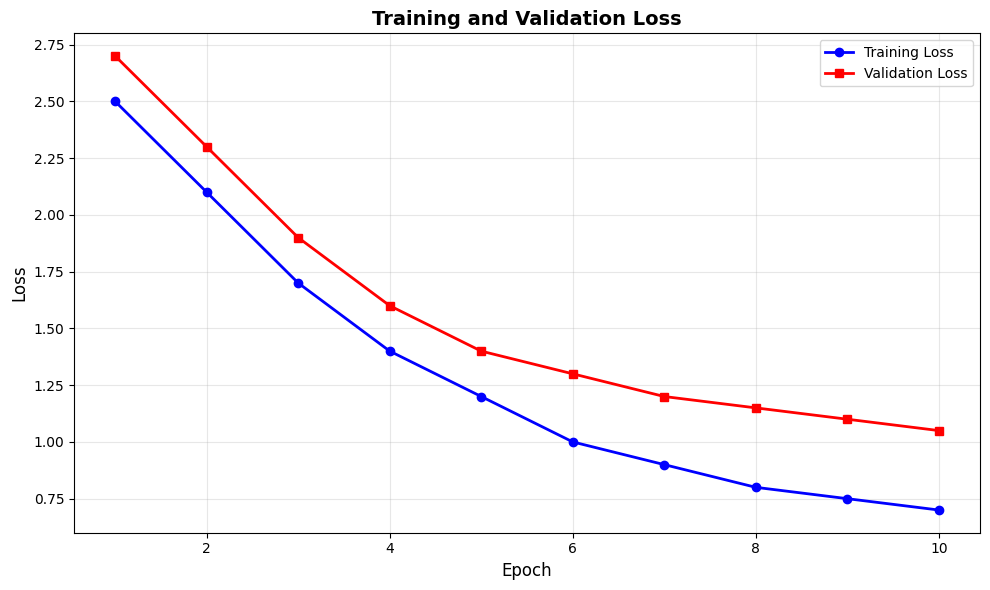


Plotting accuracy and perplexity...


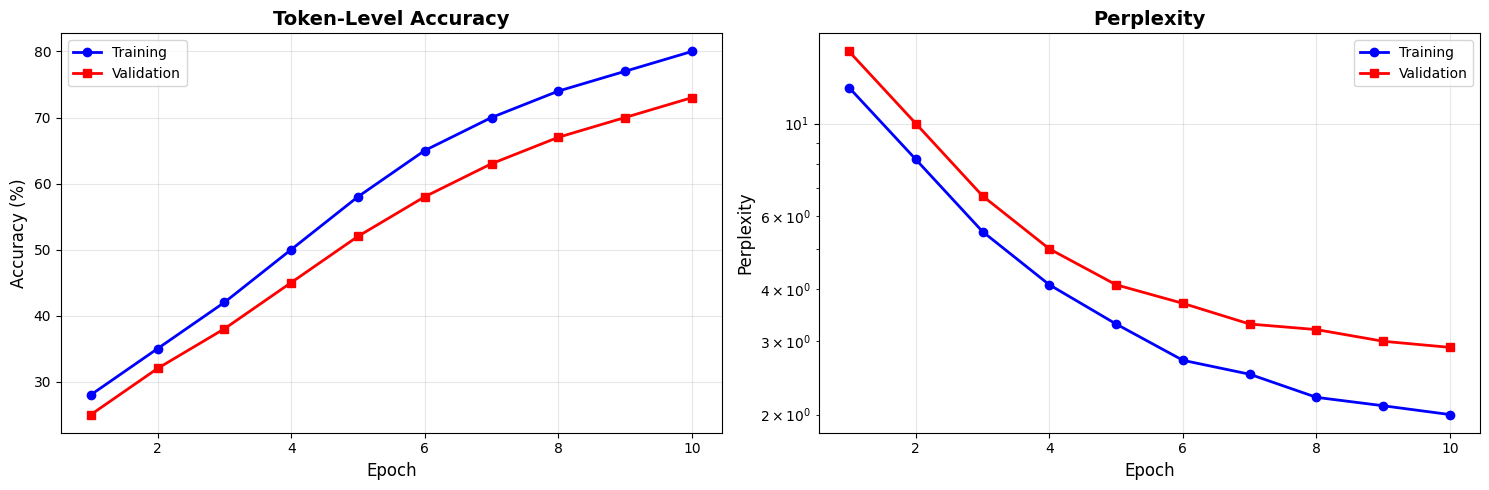


Training history plots created!


In [ ]:
from model_module.visualization import (
    plot_training_history,
    plot_metrics_history,
    print_metrics_table
)
import matplotlib.pyplot as plt

# Mock training history data (giả lập như đã train)
history = {
    'train_loss': [2.5, 2.1, 1.7, 1.4, 1.2, 1.0, 0.9, 0.8, 0.75, 0.7],
    'val_loss': [2.7, 2.3, 1.9, 1.6, 1.4, 1.3, 1.2, 1.15, 1.1, 1.05],
    'train_acc': [28, 35, 42, 50, 58, 65, 70, 74, 77, 80],
    'val_acc': [25, 32, 38, 45, 52, 58, 63, 67, 70, 73],
    'train_ppl': [12.2, 8.2, 5.5, 4.1, 3.3, 2.7, 2.5, 2.2, 2.1, 2.0],
    'val_ppl': [14.9, 10.0, 6.7, 5.0, 4.1, 3.7, 3.3, 3.2, 3.0, 2.9]
}

# Plot 1: Loss over epochs
print("\nPlotting training loss...")
plot_training_history(history)

# Plot 2: Accuracy and Perplexity
print("\nPlotting accuracy and perplexity...")
plot_metrics_history(history)

print("\nTraining history plots created!")


                   QA Evaluation Metrics                    
exact_match :  45.5000
f1          :  62.3000
bleu        :  38.7000
rouge_l     :  55.2000


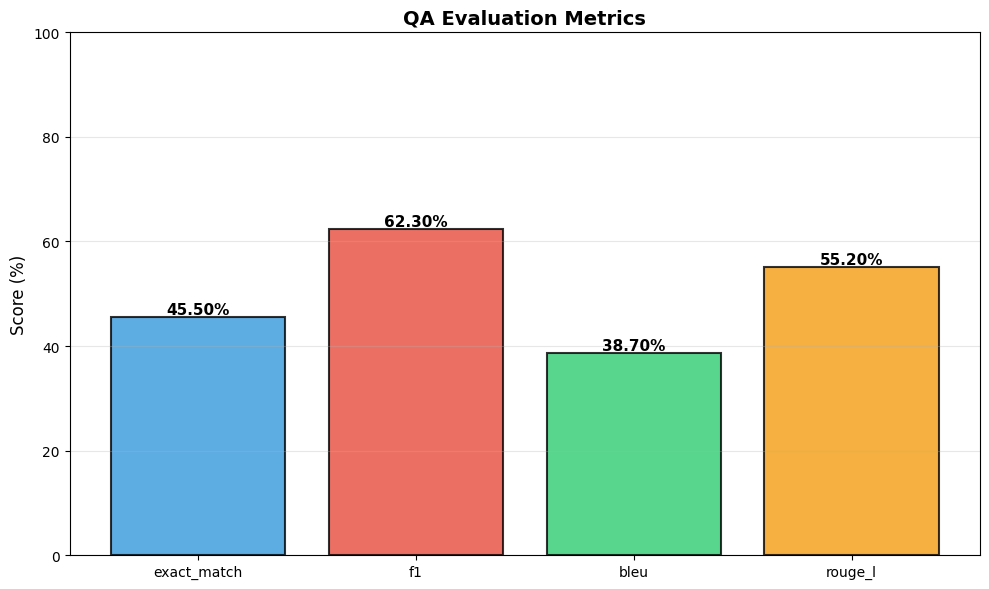


QA metrics visualization working!


In [ ]:
from model_module.visualization import plot_qa_metrics, print_metrics_table

# Mock QA metrics
qa_metrics = {
    'exact_match': 45.5,
    'f1': 62.3,
    'bleu': 38.7,
    'rouge_l': 55.2
}

# Print as table
print_metrics_table(qa_metrics, title="QA Evaluation Metrics")

# Plot bar chart
plot_qa_metrics(qa_metrics)

print("\nQA metrics visualization working!")

✓ Complete summary saved to test_complete_summary.png


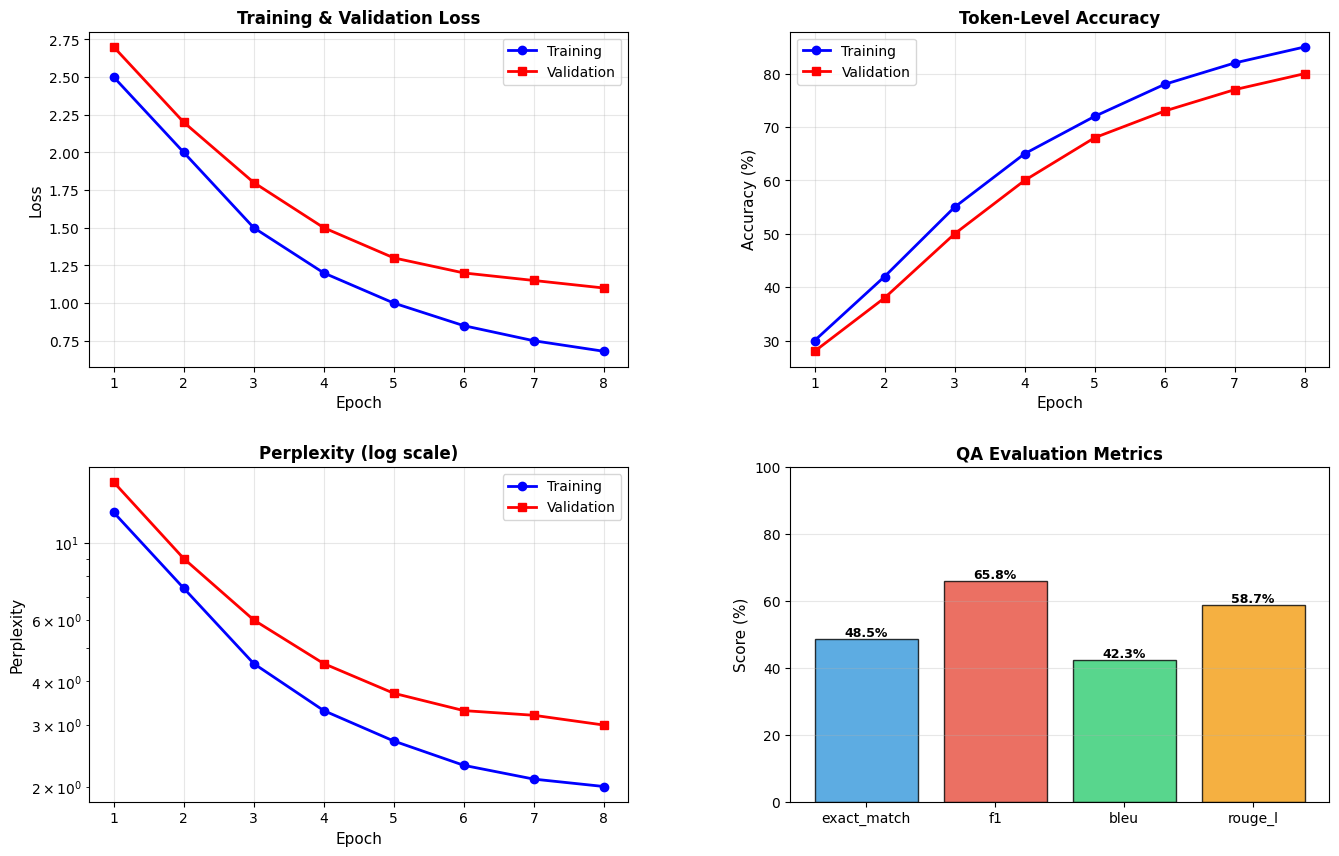


Complete summary created and saved!


In [ ]:
from model_module.visualization import plot_complete_summary

# Tạo summary với cả training history và QA metrics
history = {
    'train_loss': [2.5, 2.0, 1.5, 1.2, 1.0, 0.85, 0.75, 0.68],
    'val_loss': [2.7, 2.2, 1.8, 1.5, 1.3, 1.2, 1.15, 1.1],
    'train_acc': [30, 42, 55, 65, 72, 78, 82, 85],
    'val_acc': [28, 38, 50, 60, 68, 73, 77, 80],
    'train_ppl': [12.2, 7.4, 4.5, 3.3, 2.7, 2.3, 2.1, 2.0],
    'val_ppl': [14.9, 9.0, 6.0, 4.5, 3.7, 3.3, 3.2, 3.0]
}

qa_metrics = {
    'exact_match': 48.5,
    'f1': 65.8,
    'bleu': 42.3,
    'rouge_l': 58.7
}

# Plot everything in one figure
plot_complete_summary(history, qa_metrics, save_path='test_complete_summary.png')

print("\nComplete summary created and saved!")

### Inference

In [ ]:
del sys.modules["model_module.inference"]

In [ ]:
from model_module.inference import predict
import torch

# Đảm bảo model ở eval mode
model.eval()

# Lấy 1 sample từ validation set
test_sample = val_qa[0]

print(f"Question: {test_sample['question']}")
print(f"Entities: {test_sample['entities'][:5]}...")
print(f"True Answer: {test_sample['answers'][0][:80]}...")
print("\nPredicting...")

# Predict
try:
    predicted_answer = predict(
        model=model,
        question=test_sample['question'],
        context=test_sample['context'],
        entities=test_sample['entities'],
        kg=medical_kg,
        tokenizer=tokenizer,
        device=config.device,
        max_len=50
    )

    print(f"\nPredicted Answer: {predicted_answer}")

    # Calculate metrics for this prediction
    from model_module.metrics import exact_match_score, f1_score, bleu_score

    em = exact_match_score(predicted_answer, test_sample['answers'][0])
    f1 = f1_score(predicted_answer, test_sample['answers'][0])
    bleu = bleu_score(predicted_answer, test_sample['answers'][0])

    print(f"\nMetrics:")
    print(f"  Exact Match: {em:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"  BLEU Score:  {bleu:.4f}")

    print("\nSingle prediction successful!")

except Exception as e:
    print(f"Error during prediction: {e}")
    import traceback
    traceback.print_exc()

Question: Hàng rào máu não có vai trò gì trong việc ngăn ngừa viêm màng não?
Entities: ['Hàng rào máu', 'não', 'ngăn ngừa', 'viêm màng não']...
True Answer: Hàng rào máu não giúp bảo vệ não không bị nhiễm trùng bằng cách ngăn cản vi khuẩ...

Predicting...

Predicted Answer: 

Metrics:
  Exact Match: 0.0000
  F1 Score:    0.0000
  BLEU Score:  0.0000

Single prediction successful!


## Main

### train

In [ ]:
modules = ["__init__", "config", "data_loader", "dataset", "inference", "knowledge_graph", "main", "metrics", "models", "train", "vihealthbert_tokenizer", "visualization"]
my_modules = ["model_module." + module for module in modules]
import sys
for module_name in my_modules:
    if module_name in sys.modules:
        del sys.modules[module_name]

In [ ]:
from model_module.main import main

main(mode='train', use_kg=True)

Model Configuration:
device                   : cuda
kg_triples_path          : data/knowledge_graph_triples.csv
neo4j_nodes_path         : data/neo4j_nodes.csv
neo4j_rels_path          : data/neo4j_relationships.csv
qa_dataset_path          : data/qa_data.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vit5
vocab_size               : None
max_seq_len              : 128
vit5_tokenizer_model     : VietAI/vit5-base
use_vncorenlp            : False
vncorenlp_path           : None
use_kg                   : True
vit5_model_name          : VietAI/vit5-base
d_model                  : 768
num_heads                : 12
num_encoder_layers       : 12
num_decoder_layers       : 12
d_ff                     : 3072
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 8
num_epochs               : 12
learning_rate            : 0.0001

Processing QA: 100%|██████████| 6379/6379 [00:00<00:00, 11257.46it/s]



Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Context: 2. Người đã mắc COVID-19 có phải là đối tượng cần trì hoãn tiêm vắc xin không?
Theo hướng dẫn tạm th...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Context: 2. Biểu hiện lâm sàng của bệnh
Thời kỳ ủ bệnh: Từ khi nhiễm virus đến khi có biểu hiện bệnh trung bì...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

...


----------------------------------------------------------------------
Skipping QA metrics (will compute on epoch 12)
----------------------------------------------------------------------

----------------------------------------------------------------------
EPOCH SUMMARY
----------------------------------------------------------------------
Train - Loss: 0.1864 | Acc: 94.36% | PPL: 1.20
Val   - Loss: 3.0611 | Acc: 72.68% | PPL: 21.35
QA Metrics: [Skipped this epoch]
----------------------------------------------------------------------

Epoch 11/12


Evaluating: 100%|██████████| 80/80 [00:19<00:00,  4.16it/s]



----------------------------------------------------------------------
Skipping QA metrics (will compute on epoch 12)
----------------------------------------------------------------------

----------------------------------------------------------------------
EPOCH SUMMARY
----------------------------------------------------------------------
Train - Loss: 0.1439 | Acc: 95.60% | PPL: 1.15
Val   - Loss: 3.3080 | Acc: 72.56% | PPL: 27.33
QA Metrics: [Skipped this epoch]
----------------------------------------------------------------------

Epoch 12/12


Training:   3%|▎         | 16/638 [00:12<08:05,  1.28it/s, loss=0.0871, acc=97.25%]


KeyboardInterrupt: 

### eval

Model Configuration:
device                   : cuda
kg_triples_path          : data/knowledge_graph_triples.csv
neo4j_nodes_path         : data/neo4j_nodes.csv
neo4j_rels_path          : data/neo4j_relationships.csv
qa_dataset_path          : data/qa_data.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vit5
vocab_size               : None
max_seq_len              : 128
vit5_tokenizer_model     : VietAI/vit5-base
use_vncorenlp            : False
vncorenlp_path           : None
use_kg                   : True
vit5_model_name          : VietAI/vit5-base
d_model                  : 768
num_heads                : 12
num_encoder_layers       : 12
num_decoder_layers       : 12
d_ff                     : 3072
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 8
num_epochs               : 12
learning_rate            : 0.0001

Processing QA: 100%|██████████| 6379/6379 [00:00<00:00, 6776.81it/s]



Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Context: 2. Người đã mắc COVID-19 có phải là đối tượng cần trì hoãn tiêm vắc xin không?
Theo hướng dẫn tạm th...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Context: 2. Biểu hiện lâm sàng của bệnh
Thời kỳ ủ bệnh: Từ khi nhiễm virus đến khi có biểu hiện bệnh trung bì...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 

Evaluating: 100%|██████████| 638/638 [04:32<00:00,  2.34it/s]



Computing QA Metrics (BLEU, ROUGE-L, BERTScore)...
Note: Vietnamese baseline not available in bert-score, rescaling disabled
      Scores will be raw values (~0.8-1.0), scaled to 0-100 for display

                    Test Set Performance                    
BLEU         :  46.7140
ROUGE-L      :  46.0173
BERTScore-F1 :  90.0012


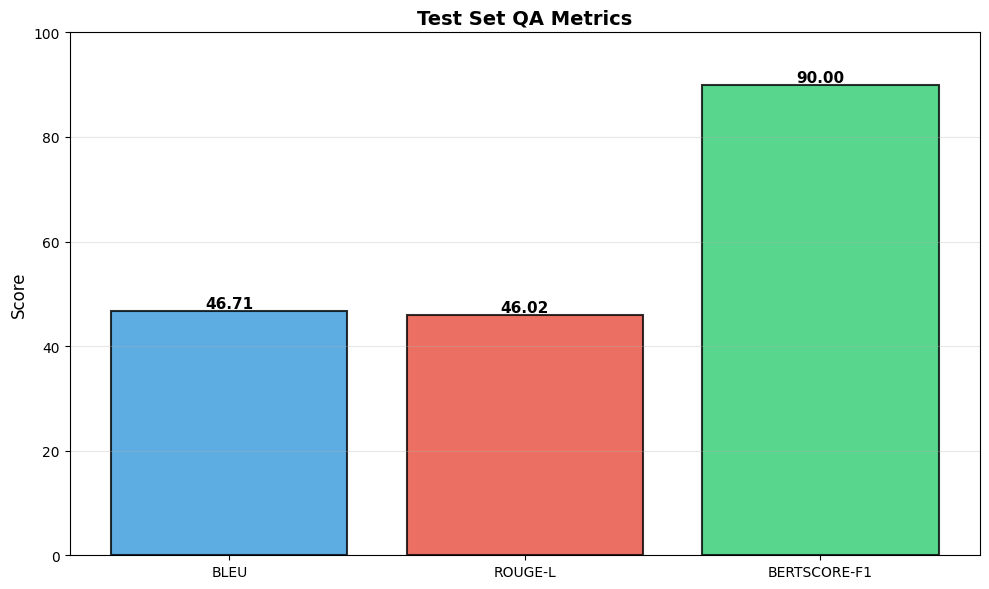


SAMPLE PREDICTIONS

Evaluating model on 5 samples...

--- Sample 1 ---
Question: Trong các triệu chứng của bệnh lý nhiễm trùng ở thận, thì dấu hiệu nào cho thấy nguy cơ nhiễm trùng ...
Entities: triệu chứng, nhiễm trùng, thận, nhiễm trùng huyết
True Answer: Nóng sốt là triệu chứng báo hiệu rất có thể tình trạng nhiễm trùng ở thận đã chu...
Predicted: Khi có nóng sốt, hãy đi khám ngay để tránh biến chứng nhiễm trùng huyết dẫn đến ...

--- Sample 2 ---
Question: Trong trường hợp áp xe má, nguyên nhân là do răng thì bác sĩ sẽ chỉ định phương pháp điều trị nào?...
Entities: áp xe, răng, chỉ định, điều trị
True Answer: Nếu áp xe má là do răng gây nên, bác sĩ sẽ điều trị tủy hoặc nhổ bỏ răng....
Predicted: Trong trường hợp áp xe má, nguyên nhân là do răng thì bác sĩ sẽ chỉ định điều tr...

--- Sample 3 ---
Question: Biến chứng nghiêm trọng nào có thể xảy ra nếu lichen xơ hóa xuất hiện ở bộ phận sinh dục?...
Entities: Biến chứng, lichen xơ hóa, bộ phận, sinh dục
True Answer: Ung thư tế bào v

In [ ]:
from model_module.main import main

main(mode='eval', use_kg=True)

### interactive

In [ ]:
from model_module.main import main

main(mode="interactive")

Model Configuration:
device                   : cuda
kg_triples_path          : data/knowledge_graph_triples.csv
neo4j_nodes_path         : data/neo4j_nodes.csv
neo4j_rels_path          : data/neo4j_relationships.csv
qa_dataset_path          : data/qa_data.csv
kg_min_confidence        : 0.95
kg_max_hops              : 2
kg_emb_dim               : 300
tokenizer_type           : vit5
vocab_size               : None
max_seq_len              : 128
vit5_tokenizer_model     : VietAI/vit5-base
use_vncorenlp            : False
vncorenlp_path           : None
use_kg                   : True
vit5_model_name          : VietAI/vit5-base
d_model                  : 768
num_heads                : 12
num_encoder_layers       : 12
num_decoder_layers       : 12
d_ff                     : 3072
gnn_hidden               : 256
gnn_type                 : gcn
gnn_layers               : 2
dropout                  : 0.1
batch_size               : 8
num_epochs               : 12
learning_rate            : 0.0001

Processing QA: 100%|██████████| 6379/6379 [00:00<00:00, 11705.36it/s]



Processed 6,379 valid QA pairs
  - Single-hop: 0
  - Multi-hop: 6,379

Example QA pairs:

--- Example 1 (2-hop) ---
ID: qa_4
Question: Vừa qua ngày 4/6 tôi có bị con chó ở nhà cắn xước ngoài da và tôi đã đến trung tâm y tế để tiêm ngừa...
Context: 2. Người đã mắc COVID-19 có phải là đối tượng cần trì hoãn tiêm vắc xin không?
Theo hướng dẫn tạm th...
Answer: Bệnh dại là bệnh nguy hiểm và nếu có chỉ định tiêm phòng vaccine thì cần được ưu...
Entities (9): ['xước', 'tiê', 'tiêm', 'ngừa', 'vaccine']

--- Example 2 (2-hop) ---
ID: qa_7
Question: Mệt mỏi, ngạt mũi có phải triệu chứng bệnh viêm đường hô hấp không?...
Context: 2. Biểu hiện lâm sàng của bệnh
Thời kỳ ủ bệnh: Từ khi nhiễm virus đến khi có biểu hiện bệnh trung bì...
Answer: Các triệu chứng bạn liệt kê ở trên hoàn toàn có thể là những dấu hiệu ban đầu củ...
Entities (5): ['Mệt mỏi', 'ngạt mũi', 'triệu chứng', 'viêm', 'đường hô hấp']

--- Example 3 (2-hop) ---
ID: qa_11
Question: Em đang điều trị ARV được 3 năm và CD4 ổn định ~500 

## Prepare for Huggingface

In [ ]:
"""
Script to prepare model files for Hugging Face upload
This script downloads base ViT5 model files and creates necessary config files
"""
import os
import json
import shutil
from transformers import T5ForConditionalGeneration, T5Tokenizer, T5Config
from huggingface_hub import snapshot_download

# Configuration
BASE_MODEL_NAME = "VietAI/vit5-base"
OUTPUT_DIR = "model_hf"
MODEL_NAME = "your-username/your-model-name"  # Update this with your HF username/model name

# Evaluation metrics
METRICS = {
    "BLEU": 46.71,
    "ROUGE-L": 46.01,
    "BERTscore-F1": 90.00
}

def create_output_dir():
    """Create output directory"""
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Created directory: {OUTPUT_DIR}")

def download_base_model_files():
    """Download base model files from Hugging Face"""
    print(f"\nStep 1: Downloading base model files from {BASE_MODEL_NAME}...")

    try:
        # Download model files
        model_path = snapshot_download(
            repo_id=BASE_MODEL_NAME,
            cache_dir=None,
            local_dir=os.path.join(OUTPUT_DIR, "temp_base")
        )

        # Copy necessary files to output directory
        files_to_copy = [
            "config.json",
            "tokenizer_config.json",
            "spiece.model",
            "special_tokens_map.json",
            "vocab.txt"  # If exists
        ]

        temp_dir = os.path.join(OUTPUT_DIR, "temp_base")
        for file in files_to_copy:
            src = os.path.join(temp_dir, file)
            if os.path.exists(src):
                shutil.copy2(src, os.path.join(OUTPUT_DIR, file))
                print(f"  ✓ Copied {file}")

        # Clean up temp directory
        shutil.rmtree(temp_dir)
        print("  ✓ Base model files downloaded successfully")

    except Exception as e:
        print(f"  ⚠ Warning: Could not download from HF Hub: {e}")
        print("  → Will create files manually...")
        create_files_manually()

def create_files_manually():
    """Create files manually by loading model"""
    print("\nStep 1 (Alternative): Creating files from loaded model...")

    try:
        # Load tokenizer and model to get files
        tokenizer = T5Tokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
        config = T5Config.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)

        # Save tokenizer files
        tokenizer.save_pretrained(OUTPUT_DIR)
        print("  ✓ Saved tokenizer files")

        # Save config
        config.save_pretrained(OUTPUT_DIR)
        print("  ✓ Saved config.json")

    except Exception as e:
        print(f"  ✗ Error creating files: {e}")
        print("  → Please ensure you have internet connection and transformers installed")

def create_generation_config():
    """Create generation_config.json"""
    print("\nStep 2: Creating generation_config.json...")

    generation_config = {
        "max_length": 128,
        "min_length": 10,
        "num_beams": 4,
        "early_stopping": True,
        "temperature": 0.7,
        "do_sample": True,
        "repetition_penalty": 1.2,
        "length_penalty": 1.0,
        "no_repeat_ngram_size": 3
    }

    output_path = os.path.join(OUTPUT_DIR, "generation_config.json")
    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(generation_config, f, indent=2, ensure_ascii=False)

    print(f"  ✓ Created generation_config.json")

def create_readme():
    """Create README.md with actual metrics"""
    print("\nStep 3: Creating README.md...")

    readme_content = f"""---
language: vi
license: apache-2.0
tags:
- vietnamese
- medical
- question-answering
- abstractive-qa
- vit5
- healthcare
datasets:
- custom-medical-qa
metrics:
- bleu
- rouge-l
- bertscore
model-index:
- name: {MODEL_NAME}
  results:
  - task:
      type: abstractive-question-answering
      name: Vietnamese Medical Abstractive Question Answering
    dataset:
      name: Custom Vietnamese Medical QA Dataset
      type: custom
    metrics:
    - type: bleu
      value: {METRICS['BLEU']:.2f}
      name: BLEU Score
    - type: rouge-l
      value: {METRICS['ROUGE-L']:.2f}
      name: ROUGE-L Score
    - type: bertscore-f1
      value: {METRICS['BERTscore-F1']:.2f}
      name: BERTScore F1
base_model: {BASE_MODEL_NAME}
---

# {MODEL_NAME}

Vietnamese Medical Abstractive Question Answering Model based on ViT5 (Vietnamese T5).

## Model Description

This model is fine-tuned from `{BASE_MODEL_NAME}` for Vietnamese medical question answering tasks. The model uses an encoder-decoder architecture and is trained on a custom Vietnamese medical dataset with knowledge graph enhancement.

### Key Features

- **Architecture**: T5 (Encoder-Decoder Transformer)
- **Base Model**: {BASE_MODEL_NAME}
- **Language**: Vietnamese
- **Domain**: Medical/Healthcare
- **Input Format**: Question + Context (retrieved via BM25)
- **Output**: Abstractive answer in Vietnamese

## Model Performance

The model was evaluated on a test set with the following metrics:

| Metric | Score |
|--------|-------|
| **BLEU** | {METRICS['BLEU']:.2f} |
| **ROUGE-L** | {METRICS['ROUGE-L']:.2f} |
| **BERTScore-F1** | {METRICS['BERTscore-F1']:.2f} |

## Usage

### Basic Usage

```python
from transformers import T5ForConditionalGeneration, T5Tokenizer

model_name = "{MODEL_NAME}"
model = T5ForConditionalGeneration.from_pretrained(model_name, trust_remote_code=True)
tokenizer = T5Tokenizer.from_pretrained(model_name, trust_remote_code=True)

# Prepare input
question = "Triệu chứng của bệnh tiểu đường là gì?"
context = "Bệnh tiểu đường là một bệnh mãn tính ảnh hưởng đến cách cơ thể chuyển hóa glucose..."

# Format input for ViT5
input_text = f"câu hỏi: {{question}} ngữ cảnh: {{context}}"

# Tokenize
inputs = tokenizer(input_text, max_length=512, truncation=True, return_tensors="pt")

# Generate
outputs = model.generate(
    **inputs,
    max_length=128,
    num_beams=4,
    early_stopping=True,
    temperature=0.7,
    repetition_penalty=1.2
)

# Decode
answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(answer)
```

### With BM25 Retrieval

```python
from transformers import T5ForConditionalGeneration, T5Tokenizer
from rank_bm25 import BM25Okapi

# Load model
model = T5ForConditionalGeneration.from_pretrained("{MODEL_NAME}", trust_remote_code=True)
tokenizer = T5Tokenizer.from_pretrained("{MODEL_NAME}", trust_remote_code=True)

# Retrieve context using BM25
question = "Triệu chứng của bệnh tiểu đường là gì?"
# ... BM25 retrieval code ...
context = retrieved_context  # Retrieved from your knowledge base

# Generate answer
input_text = f"câu hỏi: {{question}} ngữ cảnh: {{context}}"
inputs = tokenizer(input_text, return_tensors="pt")
outputs = model.generate(**inputs, max_length=128, num_beams=4)
answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
```

## Input Format

The model expects input in the following format:

```
câu hỏi: <question> ngữ cảnh: <context>
```

Where:
- `<question>`: The medical question in Vietnamese
- `<context>`: Relevant context retrieved from knowledge base (optional but recommended)

## Training Details

- **Base Model**: {BASE_MODEL_NAME}
- **Architecture**: T5 Encoder-Decoder
- **Training Data**: Custom Vietnamese Medical QA Dataset
- **Knowledge Graph**: Enhanced with KG triplets
- **Retrieval**: BM25 for context retrieval
- **Tokenizer**: ViT5 Tokenizer (SentencePiece)

## Limitations

- The model is trained specifically for Vietnamese medical domain
- Performance may vary for questions outside the medical domain
- Context retrieval quality significantly affects answer quality
- Model may generate answers that require medical professional verification

## Citation

If you use this model, please cite:

```bibtex
@misc{{{MODEL_NAME.replace("/", "_").replace("-", "_")}}},
  title={{Vietnamese Medical Abstractive Question Answering Model}},
  author={{Your Name}},
  year={{2024}},
  publisher={{Hugging Face}},
  howpublished={{\\url{{https://huggingface.co/{MODEL_NAME}}}}}
}}
```

## License

This model is released under the Apache 2.0 license.

## Acknowledgments

- Base model: {BASE_MODEL_NAME} by VietAI
- Built for Vietnamese medical question answering applications
"""

    output_path = os.path.join(OUTPUT_DIR, "README.md")
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(readme_content)

    print(f"  ✓ Created README.md")

def create_gitattributes():
    """Create .gitattributes for Git LFS"""
    print("\nStep 4: Creating .gitattributes...")

    gitattributes = """*.safetensors filter=lfs diff=lfs merge=lfs -text
*.bin filter=lfs diff=lfs merge=lfs -text
*.pt filter=lfs diff=lfs merge=lfs -text
*.onnx filter=lfs diff=lfs merge=lfs -text
*.msgpack filter=lfs diff=lfs merge=lfs -text
*.h5 filter=lfs diff=lfs merge=lfs -text
*.ckpt filter=lfs diff=lfs merge=lfs -text
*.pth filter=lfs diff=lfs merge=lfs -text
*.tflite filter=lfs diff=lfs merge=lfs -text
*.pb filter=lfs diff=lfs merge=lfs -text
*.pkl filter=lfs diff=lfs merge=lfs -text
*.model filter=lfs diff=lfs merge=lfs -text
*.spm filter=lfs diff=lfs merge=lfs -text
"""

    output_path = os.path.join(OUTPUT_DIR, ".gitattributes")
    with open(output_path, "w") as f:
        f.write(gitattributes)

    print(f"  ✓ Created .gitattributes")

def create_upload_instructions():
    """Create upload instructions file"""
    print("\nStep 5: Creating upload instructions...")

    instructions = f"""# Instructions to Upload Model to Hugging Face

## Prerequisites

1. Install Hugging Face CLI:
   ```bash
   pip install huggingface_hub
   ```

2. Login to Hugging Face:
   ```bash
   huggingface-cli login
   ```

## Steps to Upload

### Step 1: Create Model Repository

```bash
huggingface-cli repo create {MODEL_NAME} --type model
```

### Step 2: Add Your Model Weights

Copy your trained model file (.pt) to this directory and convert it:

```bash
# Option 1: Rename if it's already in the right format
cp your_model.pt {OUTPUT_DIR}/pytorch_model.bin

# Option 2: Use the conversion script (if you have one)
python convert_pt_to_hf.py
```

### Step 3: Initialize Git and Upload

```bash
cd {OUTPUT_DIR}

# Initialize git (if not already)
git init

# Install Git LFS
git lfs install

# Add all files
git add .

# Commit
git commit -m "Add Vietnamese Medical QA model"

# Add remote
git remote add origin https://huggingface.co/{MODEL_NAME}

# Push
git push origin main
```

## File Checklist

Before uploading, ensure you have:

- [x] config.json
- [x] tokenizer_config.json
- [x] spiece.model
- [x] special_tokens_map.json
- [x] generation_config.json
- [x] README.md
- [x] .gitattributes
- [ ] pytorch_model.bin (your .pt file converted)

## Notes

- Large files (model weights) will be automatically handled by Git LFS
- Make sure your .pt file is converted to pytorch_model.bin format
- The model will be publicly available unless you set it to private
"""

    output_path = os.path.join(OUTPUT_DIR, "UPLOAD_INSTRUCTIONS.md")
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(instructions)

    print(f"  ✓ Created UPLOAD_INSTRUCTIONS.md")

def create_model_card_template():
    """Create a template for additional model card information"""
    print("\nStep 6: Creating model card template...")

    template = """# Additional Model Information

## Training Configuration

- Base Model: VietAI/vit5-base
- Architecture: T5 Encoder-Decoder
- Max Sequence Length: 512 (input), 128 (output)
- Batch Size: 8
- Learning Rate: 1e-4
- Epochs: 12
- Optimizer: AdamW
- Scheduler: ReduceLROnPlateau

## Data Information

- Training Data: Custom Vietnamese Medical QA Dataset
- Knowledge Graph: Enhanced with KG triplets
- Retrieval Method: BM25
- Data Split: 80% train, 20% test

## Model Architecture Details

- Encoder Layers: 12
- Decoder Layers: 12
- Hidden Size: 768
- Attention Heads: 12
- Feed Forward Dimension: 3072
- Vocabulary Size: 32,000 (ViT5 tokenizer)

## Usage Recommendations

1. Always provide context when possible (retrieved via BM25)
2. Questions should be in Vietnamese medical domain
3. For best results, use retrieved context from knowledge base
4. Consider post-processing for medical terminology

## Known Issues

- May generate generic answers for very specific medical questions
- Performance depends on quality of retrieved context
- Should be used as assistant, not replacement for medical professionals
"""

    output_path = os.path.join(OUTPUT_DIR, "MODEL_CARD.md")
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(template)

    print(f"  ✓ Created MODEL_CARD.md")

def main():
    """Main function"""
    print("=" * 60)
    print("Preparing Model Files for Hugging Face Upload")
    print("=" * 60)

    create_output_dir()
    download_base_model_files()
    create_generation_config()
    create_readme()
    create_gitattributes()
    create_upload_instructions()
    create_model_card_template()

    print("\n" + "=" * 60)
    print("✅ All files created successfully!")
    print("=" * 60)
    print(f"\n📁 Files created in: {OUTPUT_DIR}/")
    print("\n📋 Next steps:")
    print("1. Copy your .pt model file to this directory")
    print("2. Convert .pt to pytorch_model.bin (or use safetensors)")
    print("3. Follow instructions in UPLOAD_INSTRUCTIONS.md")
    print(f"4. Upload to: https://huggingface.co/{MODEL_NAME}")

if __name__ == "__main__":
    try:
        from huggingface_hub import snapshot_download
    except ImportError:
        print("Installing huggingface_hub...")
        import subprocess
        subprocess.check_call(["pip", "install", "huggingface_hub"])
        from huggingface_hub import snapshot_download

    main()



Preparing Model Files for Hugging Face Upload
Created directory: model_hf

Step 1: Downloading base model files from VietAI/vit5-base...


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

flax_model.msgpack:   0%|          | 0.00/904M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

tf_model.h5:   0%|          | 0.00/904M [00:00<?, ?B/s]

  ✓ Copied config.json
  ✓ Copied tokenizer_config.json
  ✓ Copied spiece.model
  ✓ Copied special_tokens_map.json
  ✓ Base model files downloaded successfully

Step 2: Creating generation_config.json...
  ✓ Created generation_config.json

Step 3: Creating README.md...
  ✓ Created README.md

Step 4: Creating .gitattributes...
  ✓ Created .gitattributes

Step 5: Creating upload instructions...
  ✓ Created UPLOAD_INSTRUCTIONS.md

Step 6: Creating model card template...
  ✓ Created MODEL_CARD.md

✅ All files created successfully!

📁 Files created in: model_hf/

📋 Next steps:
1. Copy your .pt model file to this directory
2. Convert .pt to pytorch_model.bin (or use safetensors)
3. Follow instructions in UPLOAD_INSTRUCTIONS.md
4. Upload to: https://huggingface.co/your-username/your-model-name


In [ ]:
!pip install huggingface_hub
!huggingface-cli login

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: fineGrained).
The token `dl_medqa` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.

In [ ]:
"""
Script to convert best_model.pt to Hugging Face format with KG encoder
"""
import torch
import os
import sys

# Add model_hf to path to import custom model
sys.path.insert(0, 'model_hf')

from modeling_vit5_kg import KGEnhancedViT5
from transformers import T5Tokenizer

BASE_MODEL_NAME = "VietAI/vit5-base"
MODEL_PT_PATH = "best_model.pt"
OUTPUT_DIR = "model_hf"

def convert_pt_to_hf():
    """Convert .pt model to Hugging Face format with KG encoder"""

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    print(f"\nStep 1: Loading base model: {BASE_MODEL_NAME}")
    # Load base T5 config
    from transformers import T5Config
    config = T5Config.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)

    # Create custom model with KG encoder
    model = KGEnhancedViT5.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
    print("✓ Base model loaded with KG encoder structure")

    print(f"\nStep 2: Loading trained weights from: {MODEL_PT_PATH}")
    checkpoint = torch.load(MODEL_PT_PATH, map_location="cpu", weights_only=False)

    # Extract state dict
    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif "model" in checkpoint:
        state_dict = checkpoint["model"]
    else:
        state_dict = checkpoint

    # Clean keys - remove t5_model. prefix
    print("\nStep 3: Cleaning state dict keys...")
    new_state_dict = {}
    for key, value in state_dict.items():
        new_key = key
        if key.startswith("t5_model."):
            new_key = key[9:]  # Remove "t5_model."
        elif key.startswith("model."):
            new_key = key[6:]
        elif key.startswith("module."):
            new_key = key[7:]
        new_state_dict[new_key] = value

    print(f"  Total parameters: {len(new_state_dict)}")

    # Load weights
    print("\nStep 4: Loading weights into model...")
    missing_keys, unexpected_keys = model.load_state_dict(new_state_dict, strict=False)

    if missing_keys:
        print(f"  ⚠ {len(missing_keys)} missing keys")
    else:
        print("  ✓ No missing keys!")

    if unexpected_keys:
        print(f"  ⚠ {len(unexpected_keys)} unexpected keys (these are OK if they're not critical)")
        # Filter out KG encoder keys as they should be expected
        non_kg_unexpected = [k for k in unexpected_keys if not k.startswith('kg_encoder')]
        if non_kg_unexpected:
            print(f"    Non-KG unexpected keys: {len(non_kg_unexpected)}")

    # Check KG encoder keys
    kg_keys_loaded = [k for k in new_state_dict.keys() if k.startswith('kg_encoder')]
    if kg_keys_loaded:
        print(f"  ✓ KG encoder keys loaded: {len(kg_keys_loaded)}")

    # Save model
    print("\nStep 5: Saving model...")
    model.save_pretrained(OUTPUT_DIR)
    print("  ✓ Model saved")

    # Save tokenizer
    print("\nStep 6: Saving tokenizer...")
    tokenizer = T5Tokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
    tokenizer.save_pretrained(OUTPUT_DIR)
    print("  ✓ Tokenizer saved")

    print("\n✅ Conversion completed!")
    print(f"\n📁 Files in: {OUTPUT_DIR}/")
    print("\n📋 Important files:")
    print("  - modeling_vit5_kg.py (custom model class)")
    print("  - config.json (with custom architecture)")
    print("  - pytorch_model.bin or model.safetensors")
    print("  - tokenizer files")

if __name__ == "__main__":
    convert_pt_to_hf()

The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.



Step 1: Loading base model: VietAI/vit5-base


Some weights of KGEnhancedViT5 were not initialized from the model checkpoint at VietAI/vit5-base and are newly initialized: ['kg_encoder.batch_norms.0.bias', 'kg_encoder.batch_norms.0.num_batches_tracked', 'kg_encoder.batch_norms.0.running_mean', 'kg_encoder.batch_norms.0.running_var', 'kg_encoder.batch_norms.0.weight', 'kg_encoder.batch_norms.1.bias', 'kg_encoder.batch_norms.1.num_batches_tracked', 'kg_encoder.batch_norms.1.running_mean', 'kg_encoder.batch_norms.1.running_var', 'kg_encoder.batch_norms.1.weight', 'kg_encoder.convs.0.bias', 'kg_encoder.convs.0.lin.weight', 'kg_encoder.convs.1.bias', 'kg_encoder.convs.1.lin.weight', 'kg_projection.bias', 'kg_projection.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded with KG encoder structure

Step 2: Loading trained weights from: best_model.pt

Step 3: Cleaning state dict keys...
  Total parameters: 6

Step 4: Loading weights into model...
  ⚠ 274 missing keys
  ⚠ 6 unexpected keys (these are OK if they're not critical)
    Non-KG unexpected keys: 6

Step 5: Saving model...
  ✓ Model saved

Step 6: Saving tokenizer...
  ✓ Tokenizer saved

✅ Conversion completed!

📁 Files in: model_hf/

📋 Important files:
  - modeling_vit5_kg.py (custom model class)
  - config.json (with custom architecture)
  - pytorch_model.bin or model.safetensors
  - tokenizer files
